In [4]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Carichiamo MapPLUTO Manhattan
manhattan = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\nyc_mappluto_26v1_shp\MapPLUTO.shp")

print(f"Lotti caricati: {len(manhattan)}")
print(f"CRS: {manhattan.crs}")
print(manhattan.columns.tolist())
manhattan.head()

Lotti caricati: 856614
CRS: EPSG:2263
['Borough', 'Block', 'Lot', 'CD', 'BCT2020', 'BCTCB2020', 'CT2010', 'CB2010', 'SchoolDist', 'Council', 'ZipCode', 'FireComp', 'PolicePrct', 'HealthCent', 'HealthArea', 'Sanitboro', 'SanitDistr', 'SanitSub', 'Address', 'ZoneDist1', 'ZoneDist2', 'ZoneDist3', 'ZoneDist4', 'Overlay1', 'Overlay2', 'SPDist1', 'SPDist2', 'SPDist3', 'LtdHeight', 'SplitZone', 'BldgClass', 'LandUse', 'Easements', 'OwnerType', 'OwnerName', 'LotArea', 'BldgArea', 'ComArea', 'ResArea', 'OfficeArea', 'RetailArea', 'GarageArea', 'StrgeArea', 'FactryArea', 'OtherArea', 'AreaSource', 'NumBldgs', 'NumFloors', 'UnitsRes', 'UnitsTotal', 'LotFront', 'LotDepth', 'BldgFront', 'BldgDepth', 'Ext', 'ProxCode', 'IrrLotCode', 'LotType', 'BsmtCode', 'AssessLand', 'AssessTot', 'ExemptTot', 'YearBuilt', 'YearAlter1', 'YearAlter2', 'HistDist', 'Landmark', 'BuiltFAR', 'ResidFAR', 'CommFAR', 'FacilFAR', 'BoroCode', 'BBL', 'CondoNo', 'Tract2010', 'XCoord', 'YCoord', 'ZoneMap', 'ZMCode', 'Sanborn', '

,Borough,Block,Lot,CD,BCT2020,BCTCB2020,CT2010,CB2010,SchoolDist,Council,...,MIHOption1,MIHOption2,MIHOption3,MIHOption4,TrnstZone,AffResFAR,ManuFAR,Shape_Leng,Shape_Area,geometry
0,MN,1,100,101,1000500,10005000003,5,0002,None,1,...,None,None,None,None,Beyond the Greater Transit Zone,1.0,0.0,0.0,5720.612224,"POLYGON ((980252.302 191655.61, 980265.025 191..."
1,MN,1,101,101,1000100,10001001001,1,1001,02,1,...,None,None,None,None,Beyond the Greater Transit Zone,1.0,0.0,0.0,501897.289783,"MULTIPOLYGON (((972428.829 190679.175, 972443...."
2,MN,2,3,101,1000900,10009000001,9,0001,None,1,...,None,None,None,None,Manhattan Core and Long Island City Parking Areas,12.0,0.0,0.0,4362.211401,"MULTIPOLYGON (((981176.548 194654.257, 981179...."
3,MN,3,1,101,1031900,10319001003,319,1001,02,1,...,None,None,None,None,Manhattan Core and Long Island City Parking Areas,0.0,0.0,0.0,921410.462963,"MULTIPOLYGON (((979928.232 195976.551, 980006...."
4,MN,3,4,101,1031900,10319001000,319,1000,02,1,...,None,None,None,None,Manhattan Core and Long Island City Parking Areas,0.0,0.0,0.0,2771.699758,"POLYGON ((980403.205 194731.754, 980403.031 19..."


In [5]:
# Filtriamo solo Manhattan
manhattan_only = manhattan[manhattan['Borough'] == 'MN'].copy()

print(f"Lotti Manhattan: {len(manhattan_only)}")

# Anni di costruzione
manhattan_only['YearBuilt'] = pd.to_numeric(manhattan_only['YearBuilt'], errors='coerce')
manhattan_validi = manhattan_only[manhattan_only['YearBuilt'] > 1600].copy()

print(f"Edifici con anno valido: {len(manhattan_validi)}")
print(f"Anno più antico: {manhattan_validi['YearBuilt'].min()}")
print(f"Anno più recente: {manhattan_validi['YearBuilt'].max()}")
print(f"Anno mediano: {manhattan_validi['YearBuilt'].median():.0f}")

Lotti Manhattan: 42049
Edifici con anno valido: 40048
Anno più antico: 1719
Anno più recente: 2025
Anno mediano: 1910


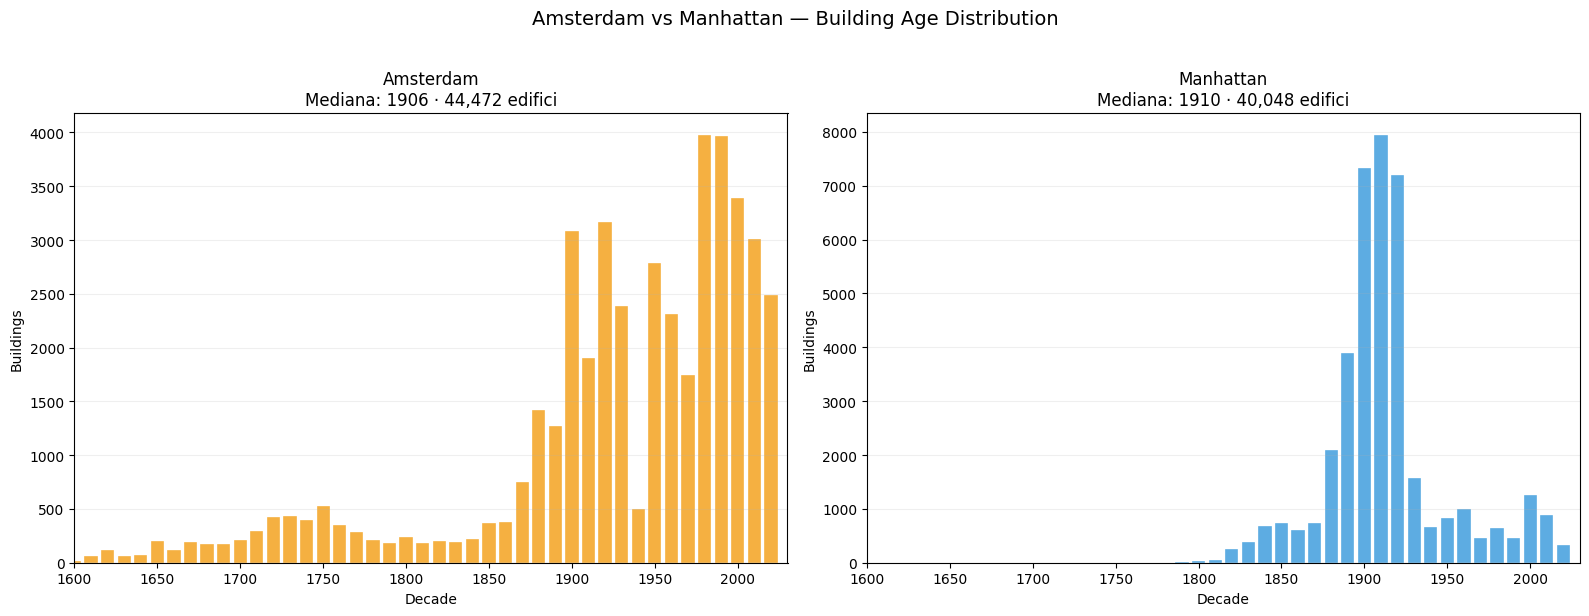

In [6]:
# Carichiamo Amsterdam
gdf = gpd.read_file(r"D:\PATRICE LAVACHE\WORK\PARAMETRIC DESIGN\geojson_lnglat.json",
                    on_invalid="ignore")
amsterdam = gdf[(gdf['Bouwjaar'] > 1600) & (gdf['Bouwjaar'] <= 2025)].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Amsterdam
amsterdam['Decennio'] = (amsterdam['Bouwjaar'] // 10) * 10
ams_per_decennio = amsterdam.groupby('Decennio').size().reset_index()
ams_per_decennio.columns = ['Decennio', 'Edifici']

ax1.bar(ams_per_decennio['Decennio'], ams_per_decennio['Edifici'],
        width=8, color='#f39c12', alpha=0.8, edgecolor='white', linewidth=0.3)
ax1.set_title(f'Amsterdam\nMediana: 1906 · {len(amsterdam):,} edifici', fontsize=12)
ax1.set_xlabel('Decade')
ax1.set_ylabel('Buildings')
ax1.grid(True, alpha=0.2, axis='y')
ax1.set_xlim(1600, 2030)

# Manhattan
manhattan_validi['Decennio'] = (manhattan_validi['YearBuilt'] // 10) * 10
man_per_decennio = manhattan_validi.groupby('Decennio').size().reset_index()
man_per_decennio.columns = ['Decennio', 'Edifici']

ax2.bar(man_per_decennio['Decennio'], man_per_decennio['Edifici'],
        width=8, color='#3498db', alpha=0.8, edgecolor='white', linewidth=0.3)
ax2.set_title(f'Manhattan\nMediana: 1910 · {len(manhattan_validi):,} edifici', fontsize=12)
ax2.set_xlabel('Decade')
ax2.set_ylabel('Buildings')
ax2.grid(True, alpha=0.2, axis='y')
ax2.set_xlim(1600, 2030)

plt.suptitle('Amsterdam vs Manhattan — Building Age Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('amsterdam_vs_manhattan_age.png', dpi=150, bbox_inches='tight')
plt.show()

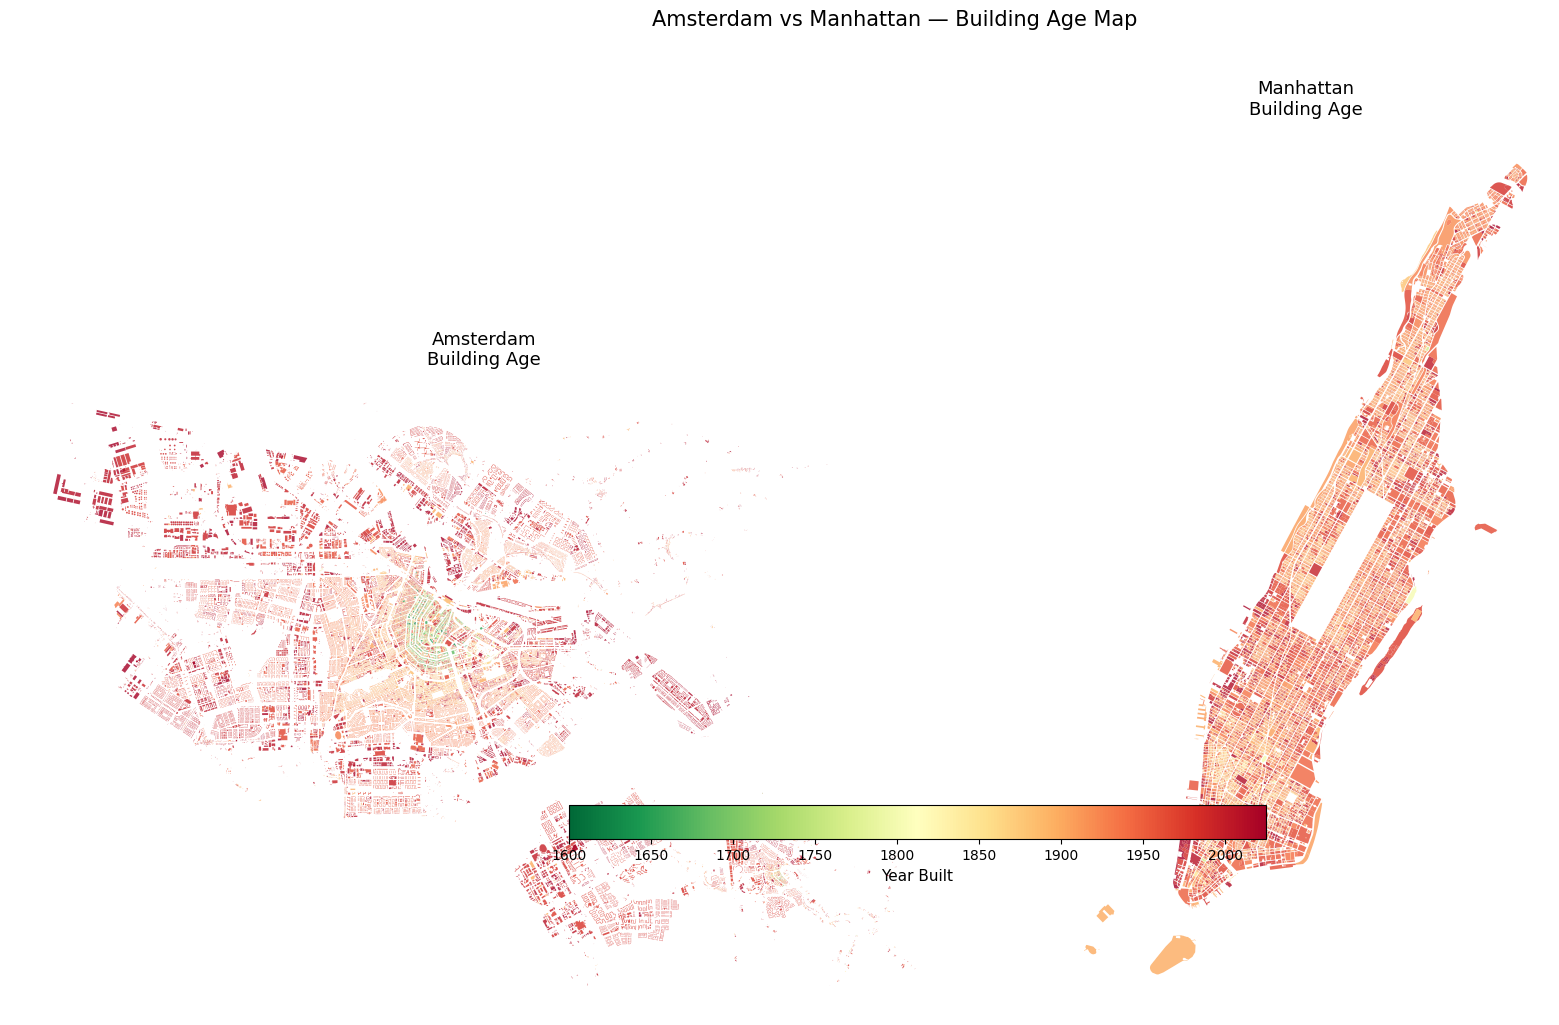

In [7]:
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))

# Normalizzazione colori uguale per entrambe le città
norm = Normalize(vmin=1600, vmax=2025)
cmap = plt.cm.RdYlGn_r

# --- AMSTERDAM ---
amsterdam_proj = amsterdam.copy()
amsterdam_proj = gpd.GeoDataFrame(amsterdam_proj, geometry='geometry')
amsterdam_proj = amsterdam_proj.to_crs("EPSG:28992")

amsterdam_proj.plot(
    column='Bouwjaar',
    cmap=cmap,
    norm=norm,
    ax=ax1,
    linewidth=0.1,
    edgecolor='none',
    alpha=0.8
)
ax1.set_title('Amsterdam\nBuilding Age', fontsize=13)
ax1.set_axis_off()

# --- MANHATTAN ---
manhattan_proj = manhattan_validi.copy()
manhattan_proj = manhattan_proj.to_crs("EPSG:3857")

manhattan_proj.plot(
    column='YearBuilt',
    cmap=cmap,
    norm=norm,
    ax=ax2,
    linewidth=0.1,
    edgecolor='none',
    alpha=0.8
)
ax2.set_title('Manhattan\nBuilding Age', fontsize=13)
ax2.set_axis_off()

# Colorbar condivisa
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=[ax1, ax2], orientation='horizontal', 
                     shrink=0.5, pad=0.02)
cbar.set_label('Year Built', fontsize=11)

plt.suptitle('Amsterdam vs Manhattan — Building Age Map', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('amsterdam_vs_manhattan_map.png', dpi=150, bbox_inches='tight')
plt.show()